In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Restaurant_Reviews.tsv", sep = "\t")

In [3]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [4]:
# Cleaning Text Data

In [5]:
import nltk
import re

In [6]:
# Stopword Removal

In [7]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
df['Review'][0]

'Wow... Loved this place.'

In [10]:
review = re.sub('[^a-zA-Z]',' ', df['Review'][0])
review

'Wow    Loved this place '

In [11]:
review = review.split()

In [12]:
review

['Wow', 'Loved', 'this', 'place']

In [ ]:
from nltk.corpus import stopwords

stopwords.words('english')


In [ ]:
stopwords.words('english')

In [17]:
preview = []
for word in review:
  if word not in stopwords.words('english'):
    preview.append(word)

In [18]:
preview

['Wow', 'Loved', 'place']

In [22]:
review = [word for word in review if word not in stopwords.words('english')]

In [23]:
review

['Wow', 'Loved', 'place']

In [26]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [27]:
review = [ps.stem(word) for word in review ]

In [28]:
review


['wow', 'love', 'place']

In [29]:
review = " ".join(review)

In [30]:
print(review)

wow love place


Main step of stopwords removal


In [32]:
corpus = []

for i in range(len(df)):
  review = re.sub('[^a-zA-Z]',' ', df['Review'][i])
  review = review.lower()
  review = review.split()

  review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
  review = " ".join(review)

  corpus.append(review)



In [33]:
print(corpus)

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch', 'servic prompt', 'would go back', 'cashier care ever say still end wayyy overpr', 'tri cape cod ravoli chicken cranberri mmmm', 'disgust pretti sure human hair', 'shock sign indic cash', 'highli recommend', 'waitress littl slow servic', 'place worth time let alon vega', 'like', 'burritto blah', 'food amaz', 'servic also cute', 'could care less interior beauti', 'perform', 'right red velvet cake ohhh stuff good', 'never brought salad ask', 'hole wall great mexican street taco friendli staff', 'took hour get food tabl restaur food luke warm sever run around like total overwhelm', 'worst salmon sashimi', 'also combo like burger fri beer decent deal', 'like final blow', 'found place accid could happier', 'seem like go

In [34]:
review

'wast enough life pour salt wound draw time took bring check'

Bag of Word Model

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

In [40]:
cv = CountVectorizer(max_features = 1000)

In [43]:
X = cv.fit_transform(corpus).toarray()

In [48]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [45]:
y = df.iloc[:,1].values

In [47]:
y.shape

(1000,)

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2,random_state =42)

In [53]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [103]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    PassiveAggressiveClassifier,
    Perceptron,
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import (
    KNeighborsClassifier,
    RadiusNeighborsClassifier,
    NearestCentroid,
)
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import *
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from tabulate import tabulate  # Import the tabulate library
from sklearn.neural_network import MLPClassifier





In [106]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from tqdm import tqdm
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM, GRU, Embedding, SimpleRNN, Dropout


# Ignore all warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import *

def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Preprocess 'previous_year_rating' column


    pipe = Pipeline([
        ('model', model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Use appropriate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred,  average="macro")
    f1 = f1_score(y_test, y_pred,  average="macro")

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, cm


# Initialize different classification models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest Classifier': RandomForestClassifier(),
    'Gradient Boosting Classifier': GradientBoostingClassifier(),
    'AdaBoost Classifier': AdaBoostClassifier(),
    'Bagging Classifier': BaggingClassifier(),
    'Extra Trees Classifier': ExtraTreesClassifier(),
    'Support Vector Classifier': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'HistGradientBoosting Classifier': HistGradientBoostingClassifier(),
    'SGD Classifier': SGDClassifier(),
    'Passive Aggressive Classifier': PassiveAggressiveClassifier(),
    'Ridge Classifier': RidgeClassifier(),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(10,), max_iter=100),

}
# Create a list to store the results
results = []

# Evaluate and print classification metrics for different models
for model_name, model in tqdm(models.items()):
    accuracy, precision, recall, f1, cm = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append([model_name, accuracy, precision, recall, f1, cm])

# Print the results in a tabular form
headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "Confusion Matrix"]
print(tabulate(results, headers, tablefmt="grid"))

max_accuracy_index = np.argmax([result[1] for result in results])
best_model_name = results[max_accuracy_index][0]
print(f"\nThe model with the highest accuracy is: {best_model_name} (Accuracy: {results[max_accuracy_index][1]:.4f})")

100%|██████████| 15/15 [00:16<00:00,  1.10s/it]

+---------------------------------+------------+-------------+----------+------------+--------------------+
| Model                           |   Accuracy |   Precision |   Recall |   F1 Score | Confusion Matrix   |
+=================================+============+=============+==========+============+====================+
| Logistic Regression             |      0.735 |    0.745495 | 0.738782 |   0.733876 | [[80 16]           |
|                                 |            |             |          |            |  [37 67]]          |
+---------------------------------+------------+-------------+----------+------------+--------------------+
| Random Forest Classifier        |      0.76  |    0.768054 | 0.763221 |   0.759398 | [[81 15]           |
|                                 |            |             |          |            |  [33 71]]          |
+---------------------------------+------------+-------------+----------+------------+--------------------+
| Gradient Boosting Classifi

In [119]:
# Ensure `y_train` has the same number of samples as `X_train_reshaped`
y_train = y_train[:X_train_reshaped.shape[0]]  # Adjust y_train to match X_train_reshaped size

# Similarly, ensure `y_test` matches the number of samples in `X_test_reshaped`
y_test = y_test[:X_test_reshaped.shape[0]]  # Adjust y_test to match X_test_reshaped size

# Verify the shapes after adjustment
print("X_train shape:", X_train_reshaped.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test_reshaped.shape)
print("y_test shape:", y_test.shape)

# Train the model
print('Training Model')
r = model.fit(X_train_reshaped, y_train, epochs=100, batch_size=32, validation_data=(X_test_reshaped, y_test),callbacks= [early_stopping])


X_train shape: (400, 1000, 2)
y_train shape: (400,)
X_test shape: (100, 1000, 2)
y_test shape: (100,)
Training Model
Epoch 1/100
13/13 [==============================] - 2s 134ms/step - loss: 0.4572 - accuracy: 0.7775 - val_loss: 1.1070 - val_accuracy: 0.4700
Epoch 2/100
13/13 [==============================] - 1s 100ms/step - loss: 0.4447 - accuracy: 0.8050 - val_loss: 0.8209 - val_accuracy: 0.5400
Epoch 3/100
13/13 [==============================] - 1s 75ms/step - loss: 0.3562 - accuracy: 0.8600 - val_loss: 0.8153 - val_accuracy: 0.5600
Epoch 4/100
13/13 [==============================] - 1s 85ms/step - loss: 0.3484 - accuracy: 0.8725 - val_loss: 0.8688 - val_accuracy: 0.5100
Epoch 5/100
13/13 [==============================] - 1s 71ms/step - loss: 0.3304 - accuracy: 0.8875 - val_loss: 0.8813 - val_accuracy: 0.5400
Epoch 6/100
13/13 [==============================] - 1s 72ms/step - loss: 0.3696 - accuracy: 0.8200 - val_loss: 0.9397 - val_accuracy: 0.5100
Epoch 7/100
13/13 [==========

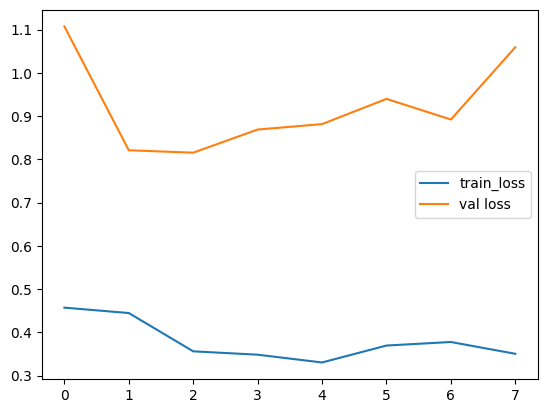

In [120]:
# Plot loss per iteration
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.legend()

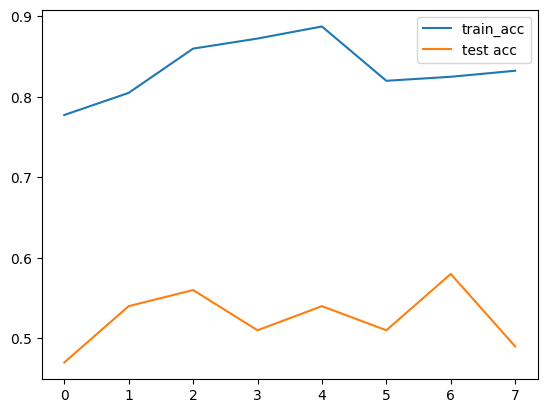

In [121]:
# Plot acc per iteration
plt.plot(r.history['accuracy'], label = 'train_acc')
plt.plot(r.history['val_accuracy'], label = 'test acc')
plt.legend()

In [125]:
# build model
i = Input(shape=(D,))
x = Dense(100, activation = 'relu')(i)
x = Dense(2)(x)

model = Model(i,x )

In [126]:
model.summary()

Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 50)]              0         
                                                                 
 dense_15 (Dense)            (None, 100)               5100      
                                                                 
 dense_16 (Dense)            (None, 2)                 202       
                                                                 
Total params: 5302 (20.71 KB)
Trainable params: 5302 (20.71 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [128]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [129]:
r = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 50,
    batch_size = 32
)

ValueError: Data cardinality is ambiguous:
  x sizes: 800
  y sizes: 400
Make sure all arrays contain the same number of samples.